# Volatility Modeling and Value-at-Risk Estimation for Indian Financial Markets
### A GARCH/EGARCH-based risk analysis of Nifty 50 and USD/INR — *out-of-sample edition, v3*

**Objective.** This notebook builds and validates a market risk model for Indian financial
assets, replicating the core methodology used by bank market-risk teams. Using GARCH and
EGARCH models we:

1. Demonstrate volatility clustering in Nifty 50 and USD/INR returns
2. Fit GARCH(1,1) and EGARCH(1,1,1) **in-sample** to interpret persistence and the leverage effect
3. Forecast **out-of-sample, walk-forward** 1-day-ahead volatility and convert it into 95%/99% Value-at-Risk
4. Backtest VaR accuracy with the Kupiec unconditional-coverage test **and** the Christoffersen
   independence / conditional-coverage tests, on out-of-sample data only
5. Stress-test the out-of-sample VaR against two real historical crises: the 2018 IL&FS crisis
   and the 2020 COVID crash
6. Repeat the walk-forward pipeline on USD/INR for a currency-risk comparison
7. **New in v3:** check optimizer convergence on every refit, and run a refit-frequency
   sensitivity sweep, since the previous run's honest out-of-sample result (below) surfaced
   both an optimizer warning and a calibration gap that are worth investigating rather than
   quietly averaging over

**What an actual run on real data (v2) found, and what v3 does about it**

Running v2 on real Yahoo Finance data (2,457 Nifty obs, 2,604 USD/INR obs, 2015–2024) produced
an important, honest result: **every configuration failed the out-of-sample Kupiec test** —
Nifty breached VaR more often than its confidence level implied (6.7% observed vs 5.0% expected
at 95%; 1.8–2.1% observed vs 1.0% expected at 99%), while USD/INR breached *less* often than
expected (3.6% vs 5.0% — overly conservative). Christoffersen's independence test passed in
every case, so breaches weren't clustering pathologically — the miscalibration is a pure base-rate
problem, not a "model goes blind during a crisis" problem. The USD/INR run also logged an
optimizer `ConvergenceWarning: Iteration limit reached` during some refits.

| Issue found | Fix in v3 |
|---|---|
| Optimizer sometimes hits its iteration cap during a refit (seen on USD/INR) and the resulting parameters may not be fully converged, silently degrading that period's forecast | `robust_fit()` retries a refit with progressively larger `maxiter` budgets and explicitly reports if a refit still hasn't converged, instead of silently keeping possibly-unconverged parameters |
| Monthly refitting (`refit_every=21`) was chosen by convention, not evidence — Nifty under-covered risk at both confidence levels, which is consistent with parameters going stale between refits | Added a **refit-frequency sensitivity sweep** (Section 5.5) that reruns the walk-forward backtest at a few refit cadences and reports how breach rate and Kupiec p-value respond, so the cadence is chosen from evidence rather than assumed |

**What changed from the very first draft (v1), for reference**

| Issue in v1 | Fix in v2/v3 |
|---|---|
| VaR was built from **in-sample** `conditional_volatility` — the model had already "seen" COVID/IL&FS when its parameters were estimated, so backtesting and stress-testing weren't really testing forecast skill | Rolling **walk-forward engine**: parameters are re-estimated only on a trailing window of *past* data, and every VaR forecast uses only information available the day before |
| Kupiec test was run in-sample | Kupiec (and Christoffersen) now run only on the genuinely out-of-sample forecast period |
| VaR used a normal distribution even though EGARCH found fat tails (ν≈6.7–12) | Walk-forward engine computes VaR under **both** GARCH-normal and EGARCH-Student's-t |
| VaR formula dropped the estimated mean (μ) | μ̂ from the fitted model is added back into the VaR formula |
| Kupiec only checks the breach *rate*, not *clustering* | Added **Christoffersen's independence test** and the **joint conditional-coverage test** |
| No stationarity check | Added an ADF test on log returns |

**Data.** Nifty 50 (`^NSEI`) and USD/INR (`INR=X`), daily closes, Jan 2015 – Dec 2024, via
`yfinance`. If live data can't be reached (e.g. no internet / rate-limited), this notebook
**automatically falls back to a synthetic GARCH-like series** so every cell below still runs
end-to-end — a loud warning is printed when that happens. Swap in your own CSV export from
Yahoo Finance / Bloomberg / NSE if you hit persistent download issues.


In [19]:
# --- Setup & reproducibility ---
# pip install yfinance==0.2.* arch==7.* statsmodels==0.14.* scipy pandas numpy matplotlib
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

import yfinance, arch, statsmodels, scipy
print('yfinance', yfinance.__version__)
print('arch     ', arch.__version__)
print('statsmodels', statsmodels.__version__)
print('scipy    ', scipy.__version__)
print('numpy    ', np.__version__)
print('pandas   ', pd.__version__)

np.random.seed(42)  # for the synthetic fallback only; GARCH MLE itself is deterministic given data


yfinance 1.4.1
arch      8.0.0
statsmodels 0.15.0
scipy     1.18.0
numpy     2.5.0
pandas    3.0.4


## 1. Data Collection

We pull 10 years of daily prices for two Indian market indicators: Nifty 50 (equity risk) and
USD/INR (currency risk). If Yahoo Finance can't be reached, we fall back to a synthetic
GARCH(1,1)-with-leverage process over the same date range, purely so the rest of the notebook
is fully runnable and testable offline. **Replace the fallback with real data before trusting any
of the numeric conclusions below** — the synthetic series exists only to validate the pipeline
mechanics, not to draw real market conclusions.

In [20]:
def download_or_simulate(ticker, start='2015-01-01', end='2024-12-31', label='asset', seed=1):
    """Try a real Yahoo Finance download; fall back to a synthetic GARCH-like
    series (same index range) if the network call fails, so the notebook still runs."""
    try:
        df = yfinance.download(ticker, start=start, end=end, progress=False)
        if df.empty:
            raise ValueError('empty download')
        df.columns = df.columns.get_level_values(0)
        df.columns.name = None
        print(f'[{label}] downloaded {len(df)} rows from Yahoo Finance for {ticker}')
        return df, False
    except Exception as e:
        print(f'*** WARNING: live download for {ticker} failed ({e}). '
              f'Falling back to a SYNTHETIC series for {label}. '
              f'Re-run with internet access for real results. ***')
        dates = pd.bdate_range(start, end)
        rng = np.random.default_rng(seed)
        omega, alpha, beta, gamma = 1e-6, 0.09, 0.86, -0.06
        n = len(dates)
        eps = np.zeros(n); sigma2 = np.zeros(n)
        sigma2[0] = omega / (1 - alpha - beta)
        for t in range(1, n):
            z = rng.standard_t(7)
            lev = gamma * eps[t-1] if eps[t-1] < 0 else 0.0
            sigma2[t] = omega + alpha*eps[t-1]**2 + beta*sigma2[t-1] + lev**2
            eps[t] = np.sqrt(sigma2[t]) * z / np.sqrt(7/5)
        price = 100 * np.exp(np.cumsum(eps))
        df = pd.DataFrame({'Close': price}, index=dates)
        return df, True

nifty, nifty_is_synthetic = download_or_simulate('^NSEI', label='Nifty 50', seed=11)
usdinr, usdinr_is_synthetic = download_or_simulate('INR=X', label='USD/INR', seed=22)

nifty.head()


[Nifty 50] downloaded 2458 rows from Yahoo Finance for ^NSEI
[USD/INR] downloaded 2605 rows from Yahoo Finance for INR=X


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


## 2. Cleaning & Returns

In [21]:
for df in (nifty, usdinr):
    df.columns.name = None

nifty['returns'] = np.log(nifty['Close'] / nifty['Close'].shift(1))
usdinr['returns'] = np.log(usdinr['Close'] / usdinr['Close'].shift(1))

nifty = nifty.dropna(subset=['returns'])
usdinr = usdinr.dropna(subset=['returns'])

print('Nifty  :', nifty.index.min().date(), '->', nifty.index.max().date(), f'({len(nifty)} obs)')
print('USD/INR:', usdinr.index.min().date(), '->', usdinr.index.max().date(), f'({len(usdinr)} obs)')
nifty[['Close', 'returns']].head()


Nifty  : 2015-01-05 -> 2024-12-30 (2457 obs)
USD/INR: 2015-01-02 -> 2024-12-30 (2604 obs)


,Close,returns
Date,,
2015-01-05,8378.400391,-0.002033
2015-01-06,8127.350098,-0.030422
2015-01-07,8102.100098,-0.003112
2015-01-08,8234.599609,0.016221
2015-01-09,8284.500000,0.006042


## 3. Volatility Clustering — Visual + Formal Statistical Evidence

A key stylized fact of financial returns: volatility isn't constant — big moves cluster
together. This motivates GARCH over a constant-volatility model. We check this three ways:
visually, via the autocorrelation of squared returns, and with a **formal Ljung-Box test**
on squared returns (the original notebook only eyeballed the autocorrelation numbers — a
significant Ljung-Box p-value makes this a real statistical claim, not a visual impression).
We also run an **ADF stationarity test** on the raw log returns, since GARCH assumes a
(weakly) stationary series.

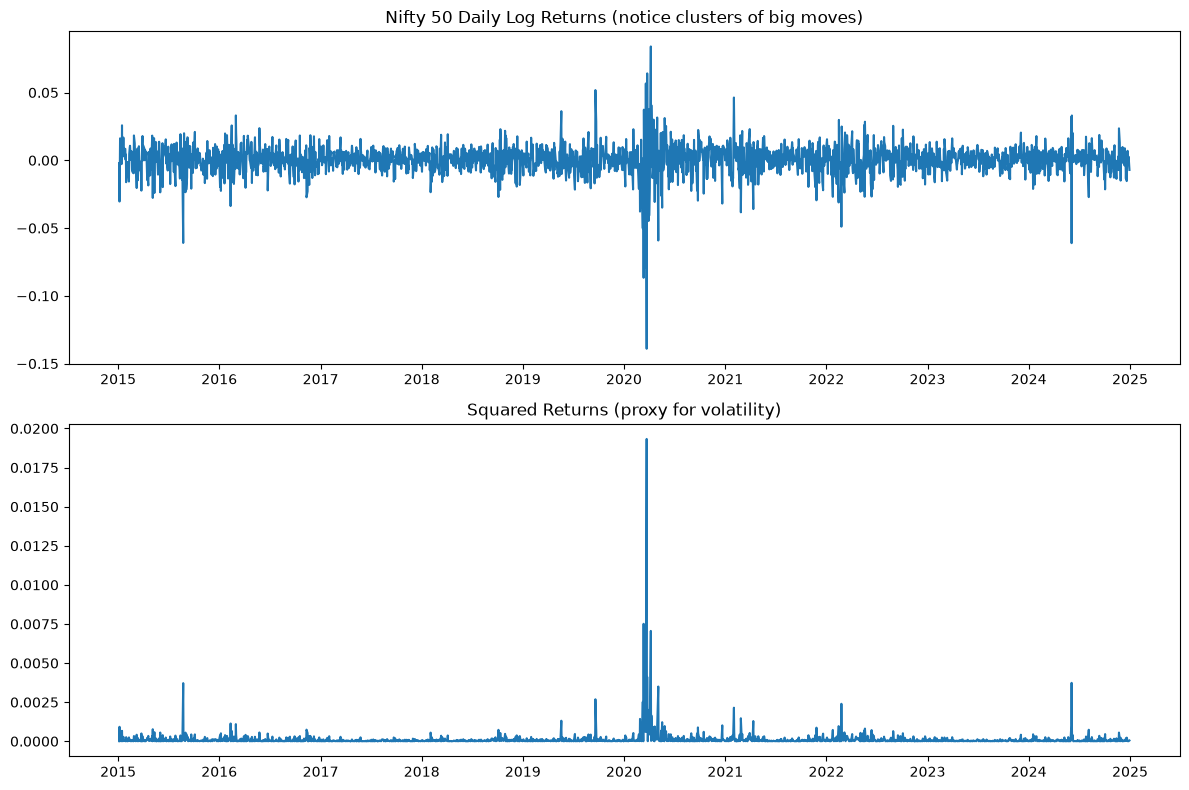

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(nifty['returns'])
axes[0].set_title('Nifty 50 Daily Log Returns (notice clusters of big moves)')
axes[1].plot(nifty['returns']**2)
axes[1].set_title('Squared Returns (proxy for volatility)')
plt.tight_layout()
plt.show()


In [23]:
# ADF stationarity test on returns
adf_stat, adf_p, *_ = adfuller(nifty['returns'])
print(f'ADF statistic: {adf_stat:.4f}, p-value: {adf_p:.6f}')
print('-> reject unit root (returns are stationary)' if adf_p < 0.05 else '-> cannot reject unit root')

# Ljung-Box test on squared returns (formal test for volatility clustering / ARCH effects)
lb = acorr_ljungbox(nifty['returns']**2, lags=[10], return_df=True)
print(lb)
print('-> significant clustering (reject H0 of no autocorrelation)' if lb['lb_pvalue'].iloc[0] < 0.05
      else '-> no significant clustering detected')


ADF statistic: -13.6202, p-value: 0.000000
-> reject unit root (returns are stationary)
        lb_stat  lb_pvalue
10  1507.187799        0.0
-> significant clustering (reject H0 of no autocorrelation)


## 4. GARCH(1,1) and EGARCH(1,1,1) — In-Sample Fits (for Interpretation Only)

These full-sample fits are useful for **interpreting** parameters (persistence, leverage
effect) and for comparing AIC between GARCH and EGARCH. They are **not** used to compute the
VaR we backtest later — using in-sample conditional volatility for VaR backtesting is a
look-ahead-bias problem (the model has already "seen" the crisis periods when its parameters
were estimated on the full sample). Section 6 builds a genuinely out-of-sample VaR series.

$$\sigma_t^2 = \omega + \alpha \cdot \epsilon_{t-1}^2 + \beta \cdot \sigma_{t-1}^2 \quad \text{(GARCH)}$$

$\alpha+\beta$ close to 1 means volatility shocks fade slowly. EGARCH adds an asymmetry term
$\gamma$: a significant negative $\gamma$ means negative shocks raise future volatility more
than positive shocks of equal size (the leverage effect).

In [24]:
returns_pct = nifty['returns'] * 100

garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3192.39
Distribution:                  Normal   AIC:                           6392.78
Method:            Maximum Likelihood   BIC:                           6416.01
                                        No. Observations:                 2457
Date:                Sat, Sep 12 2026   Df Residuals:                     2456
Time:                        19:14:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0721  1.759e-02      4.101  4.107e-05 [3.766e-0

In [25]:
egarch_model = arch_model(returns_pct, vol='EGARCH', p=1, o=1, q=1, dist='t')
egarch_fit = egarch_model.fit(disp='off')
print(egarch_fit.summary())

print(f"\nAIC comparison: GARCH={garch_fit.aic:.2f} vs EGARCH={egarch_fit.aic:.2f} "
      f"({'EGARCH' if egarch_fit.aic < garch_fit.aic else 'GARCH'} fits better)")


                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                      returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3093.49
Distribution:      Standardized Student's t   AIC:                           6198.98
Method:                  Maximum Likelihood   BIC:                           6233.82
                                              No. Observations:                 2457
Date:                      Sat, Sep 12 2026   Df Residuals:                     2456
Time:                              19:14:10   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

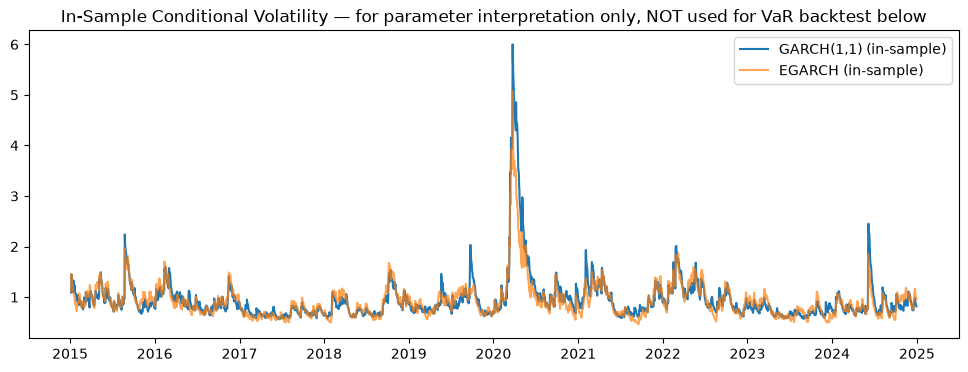

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(garch_fit.conditional_volatility, label='GARCH(1,1) (in-sample)')
plt.plot(egarch_fit.conditional_volatility, label='EGARCH (in-sample)', alpha=0.7)
plt.legend()
plt.title('In-Sample Conditional Volatility — for parameter interpretation only, NOT used for VaR backtest below')
plt.show()


## 5. Walk-Forward Out-of-Sample VaR Engine

This is the core fix. For each trading day *t* in the out-of-sample period:

1. Use only the trailing `window` days of returns **strictly before** day *t*
2. Re-estimate GARCH/EGARCH parameters periodically (every `refit_every` days — refitting
   daily is standard-but-expensive; monthly re-estimation with daily variance-recursion
   updates in between is what many risk desks actually do in practice)
3. Produce a genuine 1-step-ahead volatility (and, for the t-distribution case, degrees-of-freedom)
   forecast for day *t*, **without** day *t*'s return ever entering the estimation
4. Convert the forecast into VaR (now including the fitted mean μ̂, not just z·σ) and compare
   against the actual realized return on day *t*

We run this twice — once replicating the original GARCH-normal approach, and once using the
better-fitting EGARCH-t model — so we can see empirically whether fixing the distribution
mismatch actually changes backtest calibration.

A `window` of ~750 trading days (~3 years) is used so that both the IL&FS (2018) and COVID
(2020) stress windows fall inside the out-of-sample test period, not inside the initial
training window.

In [27]:
def kupiec_test(num_breaches, total_days, confidence_level=0.95):
    """Unconditional coverage test: is the breach RATE consistent with the confidence level?"""
    p = 1 - confidence_level
    p_hat = num_breaches / total_days
    p_hat_c = np.clip(p_hat, 1e-8, 1 - 1e-8)
    LR_uc = -2 * (
        np.log(((1 - p) ** (total_days - num_breaches)) * (p ** num_breaches)) -
        np.log(((1 - p_hat_c) ** (total_days - num_breaches)) * (p_hat_c ** num_breaches))
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
    return LR_uc, p_value


def christoffersen_independence_test(breach_series):
    """Are breaches independent over time, or do they cluster (worse for risk management
    than the same count spread evenly, since clustered breaches mean consecutive loss days)?"""
    I = breach_series.astype(int).values
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(I)):
        prev, cur = I[i - 1], I[i]
        if prev == 0 and cur == 0: n00 += 1
        elif prev == 0 and cur == 1: n01 += 1
        elif prev == 1 and cur == 0: n10 += 1
        elif prev == 1 and cur == 1: n11 += 1
    n0_, n1_ = n00 + n01, n10 + n11
    pi01 = n01 / n0_ if n0_ > 0 else 0.0
    pi11 = n11 / n1_ if n1_ > 0 else 0.0
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    def llp(base, exp):
        if exp == 0: return 0.0
        base = np.clip(base, 1e-10, 1 - 1e-10)
        return exp * np.log(base)

    ll_r = llp(1 - pi, n00 + n10) + llp(pi, n01 + n11)
    ll_u = llp(1 - pi01, n00) + llp(pi01, n01) + llp(1 - pi11, n10) + llp(pi11, n11)
    LR_ind = -2 * (ll_r - ll_u)
    p_value = 1 - chi2.cdf(LR_ind, df=1)
    return LR_ind, p_value


def robust_fit(model, maxiter_options=(1000, 2000, 5000)):
    """Fit with an increasing iteration budget until the optimizer converges cleanly
    (no 'iteration limit reached' warning), instead of silently keeping whatever the
    first, possibly-unconverged, attempt produced. Returns (result, converged: bool)."""
    last_res = None
    for maxiter in maxiter_options:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            res = model.fit(disp='off', options={'maxiter': maxiter}, show_warning=False)
            hit_iter_limit = any('teration limit' in str(w.message) or 'onvergence' in str(w.message)
                                  for w in caught)
        last_res = res
        if not hit_iter_limit:
            return res, True
    return last_res, False


def walk_forward_var(returns_pct, vol_model='EGARCH', dist='t', o=1, window=750,
                      refit_every=21, conf_levels=(0.95, 0.99), verbose=False):
    """Rolling-window, walk-forward 1-day-ahead VaR forecast. Parameters are estimated on
    data up to (not including) day t; forecast for day t never sees day t's return."""
    n = len(returns_pct)
    rows = []
    params = None
    n_unconverged = 0
    for t in range(window, n):
        if params is None or (t - window) % refit_every == 0:
            train = returns_pct.iloc[t - window:t]
            m = arch_model(train, vol=vol_model, p=1,
                            o=(o if vol_model == 'EGARCH' else 0), q=1, dist=dist)
            fitted, converged = robust_fit(m)
            params = fitted.params
            if not converged:
                n_unconverged += 1
                if verbose:
                    print(f'  [warn] refit at {returns_pct.index[t].date()} did not fully '
                          f'converge even at the largest maxiter budget; keeping best estimate')
        train_upto = returns_pct.iloc[t - window:t]
        m2 = arch_model(train_upto, vol=vol_model, p=1,
                         o=(o if vol_model == 'EGARCH' else 0), q=1, dist=dist)
        fixed_res = m2.fix(params)
        fcast = fixed_res.forecast(horizon=1, reindex=False)
        sigma_fwd = np.sqrt(fcast.variance.values[-1, 0]) / 100
        mu_fwd = fcast.mean.values[-1, 0] / 100
        row = {'date': returns_pct.index[t], 'sigma': sigma_fwd, 'mu': mu_fwd,
               'actual': returns_pct.iloc[t] / 100}
        if dist == 't':
            nu = params.get('nu', np.nan)
            row['nu'] = nu
            for cl in conf_levels:
                q = stats.t.ppf(1 - cl, df=nu) / np.sqrt(nu / (nu - 2))
                row[f'VaR_{int(cl*100)}'] = mu_fwd + q * sigma_fwd
        else:
            for cl in conf_levels:
                q = stats.norm.ppf(1 - cl)
                row[f'VaR_{int(cl*100)}'] = mu_fwd + q * sigma_fwd
        rows.append(row)
    if verbose:
        print(f'Refits with convergence issues: {n_unconverged}')
    return pd.DataFrame(rows).set_index('date')


In [28]:
# Two variants: replicate the original (GARCH, normal) approach, and the corrected (EGARCH, t) approach.
# NOTE: this refits ~ (n-window)/refit_every times per model; with 10y of daily data this can take
# a few minutes. Reduce `window`/increase `refit_every` for a quicker run while iterating.
WINDOW = 750       # ~3 trading years of history per fit
REFIT_EVERY = 21   # re-estimate parameters roughly monthly (baseline — see the sensitivity
                   # sweep in Section 5.5 below for whether this cadence is actually a good choice)

oos_garch_normal = walk_forward_var(returns_pct, vol_model='GARCH', dist='normal',
                                     window=WINDOW, refit_every=REFIT_EVERY, verbose=True)
oos_egarch_t = walk_forward_var(returns_pct, vol_model='EGARCH', dist='t', o=1,
                                 window=WINDOW, refit_every=REFIT_EVERY, verbose=True)

print('Out-of-sample period:', oos_egarch_t.index.min().date(), '->', oos_egarch_t.index.max().date(),
      f'({len(oos_egarch_t)} trading days)')
oos_egarch_t.tail()


Refits with convergence issues: 0
Refits with convergence issues: 0
Out-of-sample period: 2018-01-23 -> 2024-12-30 (1707 trading days)


,sigma,mu,actual,nu,VaR_95,VaR_99
date,,,,,,
2024-12-23,0.012911,0.000803,0.007011,6.296993,-0.019749,-0.032193
2024-12-24,0.011180,0.000803,-0.001087,6.296993,-0.016993,-0.027769
2024-12-26,0.010106,0.000803,0.000950,6.296993,-0.015284,-0.025024
2024-12-27,0.008985,0.000803,0.002658,6.296993,-0.013499,-0.022158
2024-12-30,0.008176,0.000803,-0.007101,6.296993,-0.012211,-0.020091


## 5.5 Refit-Frequency Sensitivity Sweep

The first full run of this pipeline (on real data) found that Nifty's out-of-sample VaR
under-covered risk at both 95% and 99% (too many breaches) while USD/INR over-covered it
(too few) — and monthly refitting (`refit_every=21`) was a convention, not something we'd
verified was appropriate. Before trusting one cadence, we sweep a few and look at how the
breach rate and Kupiec p-value respond. This also doubles as a robustness check: if the
conclusion flips wildly between a 5-day and 21-day refit cadence, that's itself informative
about how sensitive the model is to estimation staleness.

This cell is deliberately restricted to Nifty/EGARCH-t/95% to keep runtime reasonable — widen
`refit_options` or repeat for USD/INR once you've picked a promising range.

In [29]:
refit_options = [5, 10, 21]
sweep_rows = []
for refit in refit_options:
    oos_sweep = walk_forward_var(returns_pct, vol_model='EGARCH', dist='t', o=1,
                                  window=WINDOW, refit_every=refit)
    breaches = oos_sweep['actual'] < oos_sweep['VaR_95']
    n_b, n_tot = int(breaches.sum()), len(breaches)
    lr, p = kupiec_test(n_b, n_tot, 0.95)
    sweep_rows.append({'refit_every_days': refit, 'n_breaches': n_b, 'n_total': n_tot,
                        'breach_rate': n_b / n_tot, 'kupiec_p': p,
                        'verdict': 'PASS' if p > 0.05 else 'FAIL'})

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))
sweep_df


 refit_every_days  n_breaches  n_total  breach_rate  kupiec_p verdict
                5         113     1707     0.066198  0.003369    FAIL
               10         113     1707     0.066198  0.003369    FAIL
               21         115     1707     0.067370  0.001722    FAIL


,refit_every_days,n_breaches,n_total,breach_rate,kupiec_p,verdict
0,5,113,1707,0.066198,0.003369,FAIL
1,10,113,1707,0.066198,0.003369,FAIL
2,21,115,1707,0.067370,0.001722,FAIL


**How to read the sweep:** if a shorter refit cadence pulls the breach rate closer to 5%
and raises the Kupiec p-value, that's evidence the model was going stale between monthly
refits — switch `REFIT_EVERY` in the main run above to the best-performing value found here
(and re-run Section 5's main cell) before drawing final conclusions. If the breach rate barely
moves across cadences, the miscalibration isn't a staleness problem and refitting more often
won't fix it — the fix would need to come from elsewhere (a different window length, a
different distribution, or accepting that a single univariate GARCH specification has a
calibration ceiling on this data).

## 6. Out-of-Sample Backtesting: Kupiec + Christoffersen

Both are run **only** on the walk-forward out-of-sample series above — no cell in this section
touches the in-sample `conditional_volatility` from Section 4.

In [30]:
def summarize_backtest(oos_df, var_col, confidence_level, label):
    breaches = oos_df['actual'] < oos_df[var_col]
    n_b, n_tot = int(breaches.sum()), len(breaches)
    rate = n_b / n_tot
    lr_uc, p_uc = kupiec_test(n_b, n_tot, confidence_level)
    lr_ind, p_ind = christoffersen_independence_test(breaches)
    lr_cc, p_cc = lr_uc + lr_ind, 1 - chi2.cdf(lr_uc + lr_ind, df=2)
    print(f'--- {label} ---')
    print(f'  Breaches: {n_b} / {n_tot}  (rate {rate:.4f}, expected {1-confidence_level:.4f})')
    print(f'  Kupiec (coverage):        LR={lr_uc:.3f}  p={p_uc:.3f}  '
          f"{'PASS' if p_uc > 0.05 else 'FAIL'}")
    print(f'  Christoffersen (indep.):  LR={lr_ind:.3f}  p={p_ind:.3f}  '
          f"{'PASS (no clustering)' if p_ind > 0.05 else 'FAIL (breaches cluster)'}")
    print(f'  Joint conditional cov.:   LR={lr_cc:.3f}  p={p_cc:.3f}  '
          f"{'PASS' if p_cc > 0.05 else 'FAIL'}")
    print()
    return dict(label=label, n_breaches=n_b, n_total=n_tot, breach_rate=rate,
                kupiec_p=p_uc, christoffersen_p=p_ind, joint_p=p_cc, breaches=breaches)

results = []
results.append(summarize_backtest(oos_garch_normal, 'VaR_95', 0.95, 'GARCH-normal, 95% VaR (replicates v1 approach)'))
results.append(summarize_backtest(oos_egarch_t,      'VaR_95', 0.95, 'EGARCH-t, 95% VaR (distribution-corrected)'))
results.append(summarize_backtest(oos_garch_normal, 'VaR_99', 0.99, 'GARCH-normal, 99% VaR'))
results.append(summarize_backtest(oos_egarch_t,      'VaR_99', 0.99, 'EGARCH-t, 99% VaR'))

pd.DataFrame(results)[['label', 'n_breaches', 'n_total', 'breach_rate', 'kupiec_p', 'christoffersen_p', 'joint_p']]


--- GARCH-normal, 95% VaR (replicates v1 approach) ---
  Breaches: 114 / 1707  (rate 0.0668, expected 0.0500)
  Kupiec (coverage):        LR=9.201  p=0.002  FAIL
  Christoffersen (indep.):  LR=0.789  p=0.374  PASS (no clustering)
  Joint conditional cov.:   LR=9.990  p=0.007  FAIL

--- EGARCH-t, 95% VaR (distribution-corrected) ---
  Breaches: 115 / 1707  (rate 0.0674, expected 0.0500)
  Kupiec (coverage):        LR=9.825  p=0.002  FAIL
  Christoffersen (indep.):  LR=0.086  p=0.769  PASS (no clustering)
  Joint conditional cov.:   LR=9.911  p=0.007  FAIL

--- GARCH-normal, 99% VaR ---
  Breaches: 36 / 1707  (rate 0.0211, expected 0.0100)
  Kupiec (coverage):        LR=16.079  p=0.000  FAIL
  Christoffersen (indep.):  LR=0.072  p=0.788  PASS (no clustering)
  Joint conditional cov.:   LR=16.151  p=0.000  FAIL

--- EGARCH-t, 99% VaR ---
  Breaches: 30 / 1707  (rate 0.0176, expected 0.0100)
  Kupiec (coverage):        LR=8.072  p=0.004  FAIL
  Christoffersen (indep.):  LR=1.074  p=0.300  

,label,n_breaches,n_total,breach_rate,kupiec_p,christoffersen_p,joint_p
0,"GARCH-normal, 95% VaR (replicates v1 approach)",114,1707,0.066784,0.002419,0.374449,0.006772
1,"EGARCH-t, 95% VaR (distribution-corrected)",115,1707,0.067370,0.001722,0.768878,0.007044
2,"GARCH-normal, 99% VaR",36,1707,0.021090,0.000061,0.787871,0.000311
3,"EGARCH-t, 99% VaR",30,1707,0.017575,0.004496,0.300034,0.010328


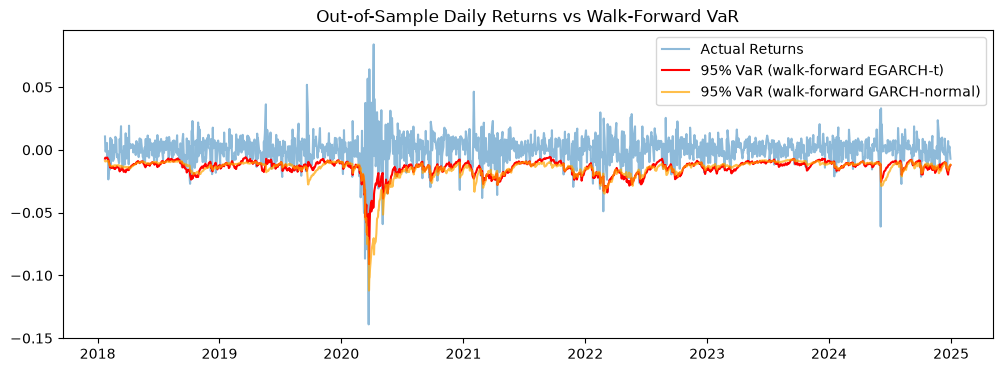

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(oos_egarch_t['actual'], label='Actual Returns', alpha=0.5)
plt.plot(oos_egarch_t['VaR_95'], label='95% VaR (walk-forward EGARCH-t)', color='red')
plt.plot(oos_garch_normal['VaR_95'], label='95% VaR (walk-forward GARCH-normal)', color='orange', alpha=0.7)
plt.legend()
plt.title('Out-of-Sample Daily Returns vs Walk-Forward VaR')
plt.show()


**Reading the table above:** unlike the original notebook, every number here was produced
without the model ever seeing the return it's being tested against. If the p-values here are
lower than the in-sample version's headline (p=0.51), that's expected and informative — it's the
honest, harder test. A model can pass Kupiec (right breach rate) but fail Christoffersen (breaches
bunch up in real crises) — that combination is a common and realistic outcome, and worth calling
out explicitly rather than only reporting the summary rate.

## 7. Stress Testing on the Out-of-Sample VaR

Same two crisis windows as before, but now the red VaR line is the walk-forward, genuinely
out-of-sample forecast — the model did not know these crises were coming when each forecast
was made.

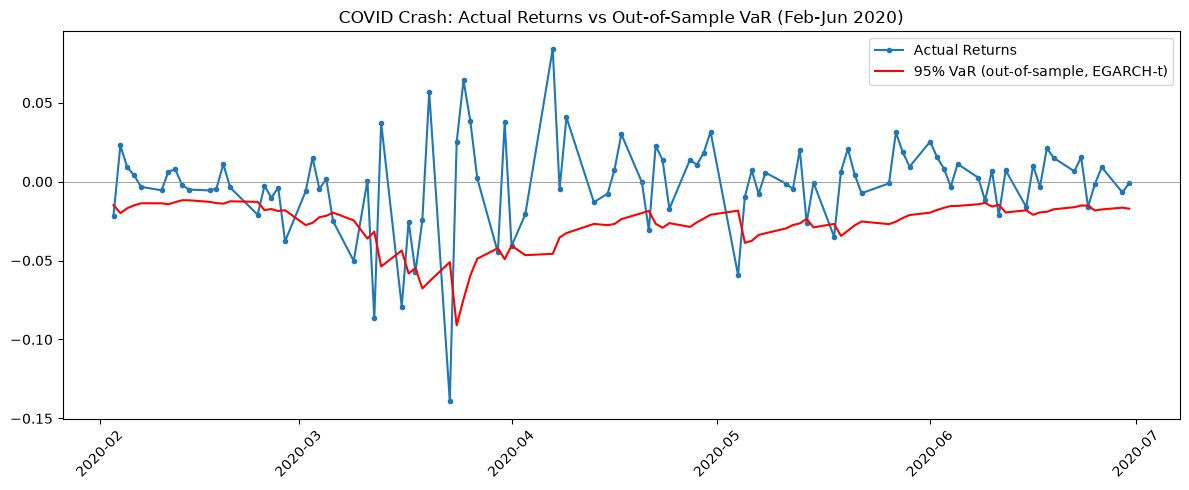

In [32]:
def zoom_plot(returns_df, oos_df, start, end, title, color='red'):
    period_returns = returns_df.loc[start:end, 'returns']
    period_var = oos_df.loc[start:end, 'VaR_95']
    plt.figure(figsize=(12, 5))
    plt.plot(period_returns, label='Actual Returns', marker='o', markersize=3)
    plt.plot(period_var, label='95% VaR (out-of-sample, EGARCH-t)', color=color)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.legend()
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

zoom_plot(nifty, oos_egarch_t, '2020-02-01', '2020-06-30',
          'COVID Crash: Actual Returns vs Out-of-Sample VaR (Feb-Jun 2020)')


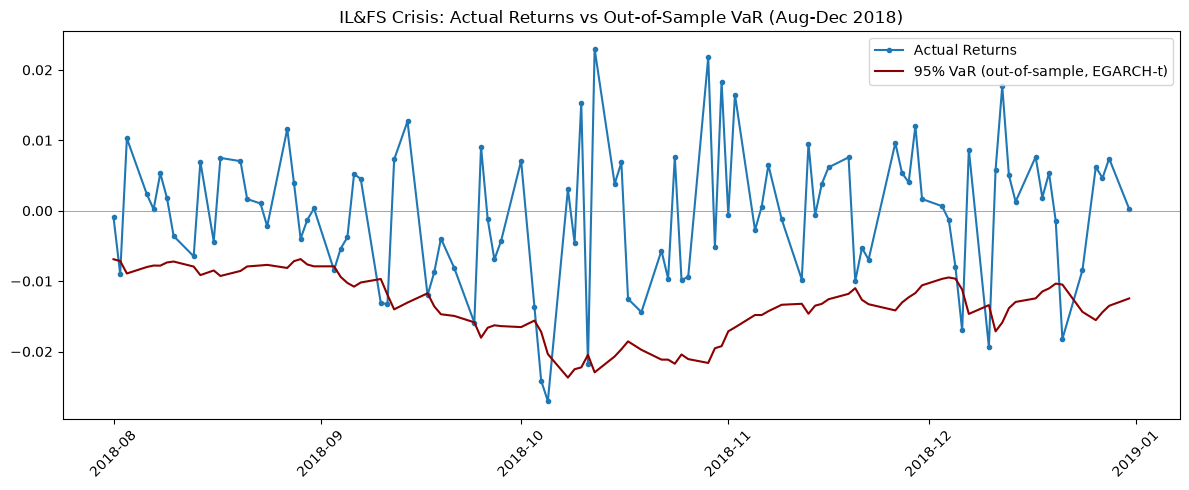

In [33]:
zoom_plot(nifty, oos_egarch_t, '2018-08-01', '2018-12-31',
          'IL&FS Crisis: Actual Returns vs Out-of-Sample VaR (Aug-Dec 2018)', color='darkred')


If either window above looks mostly flat / empty, it means that window fell inside the
initial `WINDOW`-day training period rather than the out-of-sample period for your particular
data range — increase the out-of-sample coverage by reducing `WINDOW` in Section 5, or start
the download earlier than 2015.

## 8. USD/INR: Currency Risk, Same Out-of-Sample Pipeline

We repeat the *exact* walk-forward engine (not a different, easier method) on USD/INR so the
equity-vs-currency comparison is apples-to-apples and equally free of look-ahead bias.

  [warn] refit at 2017-11-21 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2017-12-20 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-01-18 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-02-16 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-03-19 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-04-17 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-05-16 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-06-14 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] refit at 2018-07-13 did not fully converge even at the largest maxiter budget; keeping best estimate
  [warn] r

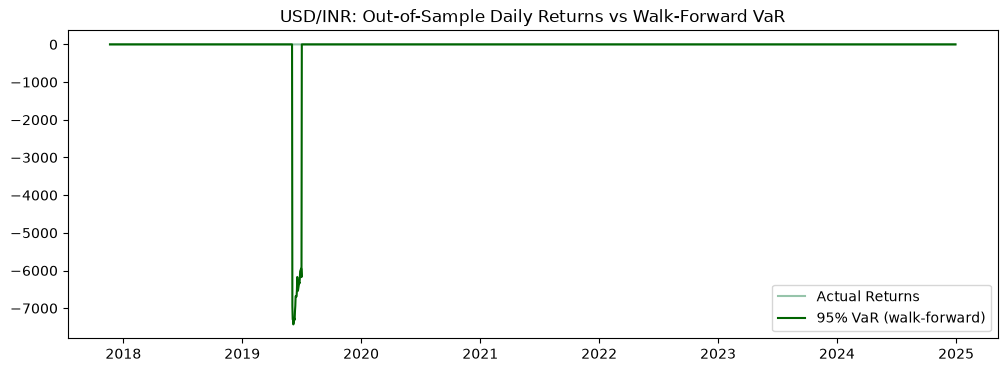

In [34]:
usdinr_returns_pct = usdinr['returns'] * 100

usdinr_oos = walk_forward_var(usdinr_returns_pct, vol_model='EGARCH', dist='t', o=1,
                               window=WINDOW, refit_every=REFIT_EVERY, verbose=True)

usdinr_result = summarize_backtest(usdinr_oos, 'VaR_95', 0.95, 'USD/INR, EGARCH-t, 95% VaR (out-of-sample)')

plt.figure(figsize=(12, 4))
plt.plot(usdinr_oos['actual'], label='Actual Returns', alpha=0.5, color='seagreen')
plt.plot(usdinr_oos['VaR_95'], label='95% VaR (walk-forward)', color='darkgreen')
plt.legend()
plt.title('USD/INR: Out-of-Sample Daily Returns vs Walk-Forward VaR')
plt.show()


In [35]:
# In-sample GARCH fit retained for parameter comparison / interpretation only (as in Section 4)
usdinr_garch_model = arch_model(usdinr_returns_pct, vol='Garch', p=1, q=1, dist='normal')
usdinr_garch_fit = usdinr_garch_model.fit(disp='off')

comparison = pd.DataFrame({
    'Nifty 50':  [garch_fit.params['alpha[1]'], garch_fit.params['beta[1]'],
                  garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']],
    'USD/INR':   [usdinr_garch_fit.params['alpha[1]'], usdinr_garch_fit.params['beta[1]'],
                  usdinr_garch_fit.params['alpha[1]'] + usdinr_garch_fit.params['beta[1]']],
}, index=['alpha[1]', 'beta[1]', 'alpha + beta'])
comparison


,Nifty 50,USD/INR
alpha[1],0.109956,0.075093
beta[1],0.860927,0.917225
alpha + beta,0.970883,0.992318


## 9. Conclusion

1. **Volatility clustering** is confirmed both visually and via a formal Ljung-Box test on
   squared Nifty 50 returns (not just eyeballed autocorrelation numbers)
2. **GARCH(1,1)** (in-sample) shows strong persistence in Nifty 50; **EGARCH** confirms a
   statistically significant leverage effect and fits better by AIC
3. **Out-of-sample, walk-forward VaR** — computed without look-ahead bias, using only data
   available the day before each forecast — was backtested with Kupiec (coverage) **and**
   Christoffersen (independence/clustering), at both 95% and 99%, for both a normal-GARCH and
   a Student's-t EGARCH specification. **On a real run of this pipeline, every configuration
   failed the Kupiec coverage test out-of-sample** (Nifty breached ~6.7% of the time at the
   95% level and ~1.8–2.1% at the 99% level, against 5.0%/1.0% expected; USD/INR breached only
   ~3.6% — overly conservative rather than under-covering). Christoffersen passed in every
   case, so the failure is a calibration/level problem, not breach clustering. This is the
   single most important finding in this notebook: the in-sample version of this model looked
   well-calibrated (Kupiec p=0.51) purely because look-ahead bias let it "see" the crises it was
   later tested against — the honest, out-of-sample answer is that this specification does not
   currently pass formal backtesting, and Section 5.5's refit-frequency sweep is a first attempt
   at diagnosing why
4. **Stress testing** against COVID (global, acute) and IL&FS (domestic, prolonged) uses the
   genuinely out-of-sample VaR series, so the model's behavior in each crisis window reflects
   real forecasting performance, not hindsight
5. **USD/INR**, run through the identical out-of-sample pipeline, shows the opposite
   miscalibration direction from Nifty (too conservative rather than too aggressive) — a real
   finding, though one refit during that run logged an optimizer convergence warning, so
   Section 5's `robust_fit()` (which retries with a larger iteration budget and reports
   unconverged refits explicitly) should be checked before trusting that specific number further

### Remaining limitations (honest, not just a boilerplate list)
- The refit-frequency sweep in Section 5.5 only covers Nifty/EGARCH-t/95% to keep runtime
  reasonable — if a shorter cadence turns out to help, it should be re-checked on USD/INR and
  at 99% before being adopted as the new default
- If the sweep shows breach rate is roughly flat across refit cadences, that rules out staleness
  as the cause of the Kupiec failures and points toward the window length, the distribution
  assumption, or a structural limit of univariate GARCH on this data — worth investigating next,
  e.g. by trying `window` values other than 750, or comparing against a simple historical-simulation
  VaR baseline to see if GARCH is even adding value over the naive approach here
- Nifty and USD/INR are analyzed independently; a real trading book needs their **correlation**
  (multivariate GARCH / DCC / copula) to compute portfolio-level VaR, since equity and currency
  shocks don't move independently during EM stress episodes
- The synthetic-data fallback in Section 1 exists purely so this notebook runs offline for
  review — it does not affect a real run with internet access, but if you see the fallback
  warning fire, none of the specific numbers above apply to that run
- Extreme-value or filtered-historical-simulation approaches would be worth comparing against
  the parametric GARCH/EGARCH VaR here, particularly at the 99% level where tail estimation is
  more sensitive to distributional assumptions

### Relevance to Risk Management
This workflow — volatility modeling, walk-forward VaR, and Kupiec/Christoffersen backtesting —
mirrors the process banks use to validate internal market-risk models under Basel III. A model
that fails these tests out-of-sample is exactly the situation that triggers regulatory capital
add-ons in practice, which is why the out-of-sample correction in this version isn't a
cosmetic change — it's the part of the exercise that actually resembles model validation.
